Universidade do Vale do Itajaí  
Processamento Digital de Sinais  
Docente: Walter Antônio Gotijo  
Acadêmico: Henry José  
Curso: Engenharia de Computação 8º Semestre  


a)  y[n] = ao.x[n] + a1.y[n-m1] + a2*y[n-m2]

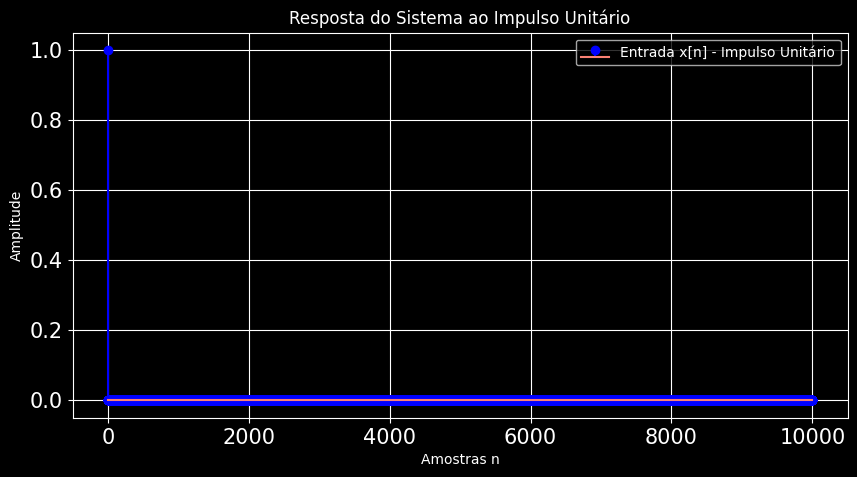

In [115]:
import numpy as np
import matplotlib.pyplot as plt

# Amostras
M1 = 350
M2 = 700


# Ganhos 1)
# a0 = 1
# a1 = 0.5
# a2 = 0.25

# Ganhos 2)
a0 = 0.7
a1 = - 0.5
a2 = - 0.5

# Número de amostras
N = 10000

# Impulso unitário
x = []
n = []

for i in range(N):
    n.append(i)

    if i == 0:
        x.append(1)
    else:
        x.append(0)

# Vetor de saída
y = np.zeros(N)

# Implementação:
# y[n] = a0*x[n] + a1*y[n-M1] + a2*y[n-M2]

for i in range(N):
    y[i] = a0 * x[i]
    if i >= M1:
        y[i] += a1 * y[i - M1]
    if i >= M2:
        y[i] += a2 * y[i - M2]

# Plotar
plt.figure(figsize=(10, 5))

plt.stem(n, x,
         linefmt='b-',
         markerfmt='bo',
         label='Entrada x[n] - Impulso Unitário')

# plt.stem(n, y,
#          linefmt='r-',
#          markerfmt='ro',
#          label='Saída y[n]')

plt.title('Resposta do Sistema ao Impulso Unitário')
plt.xlabel('Amostras n')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

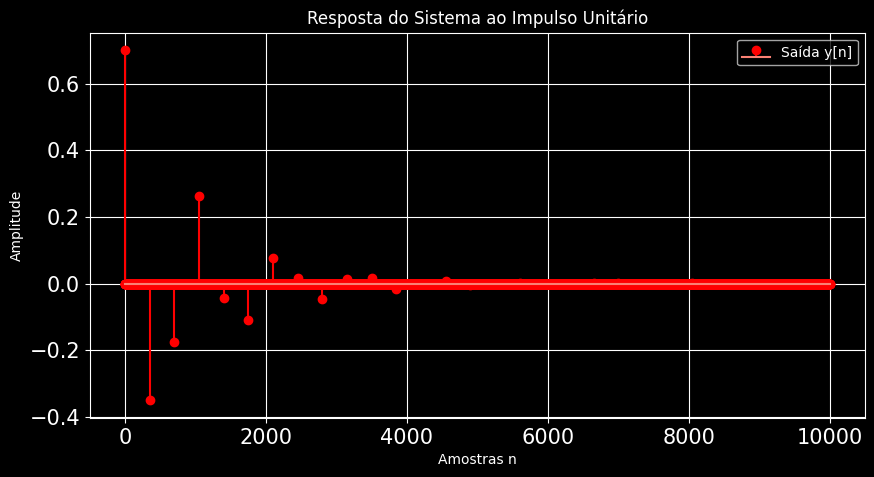

In [116]:
# Plotar
plt.figure(figsize=(10, 5))

plt.stem(n, y,
         linefmt='r-',
         markerfmt='ro',
         label='Saída y[n]')

plt.title('Resposta do Sistema ao Impulso Unitário')
plt.xlabel('Amostras n')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

In [117]:
Fs = 8000

# Ler áudio PCM
x = np.fromfile("Gravando.pcm", dtype=np.int16).astype(np.float32)

# Tamanho do áudio
tama_loop = len(x)

# Vetor de saída
vet_saida = np.zeros(tama_loop, dtype=np.float32)

# Implementação:
# y[n] = a0*x[n] + a1*y[n-M1] + a2*y[n-M2]

for i in range(tama_loop):
    vet_saida[i] = a0 * x[i]
    if i >= M1:
        vet_saida[i] += a1 * vet_saida[i - M1]
    if i >= M2:
        vet_saida[i] += a2 * vet_saida[i - M2]


# Prevenção de clipping
max_val = np.max(np.abs(vet_saida))
if max_val > 32767:
    vet_saida = (vet_saida / max_val) * 32767

vet_saida.astype(np.int16).tofile("Gravando_com_ganhos_A.pcm")

Eco = np.fromfile("Gravando_com_ganhos_A.pcm", dtype=np.int16)

Audio(x, rate=Fs)


In [118]:
Audio(Eco, rate=Fs)

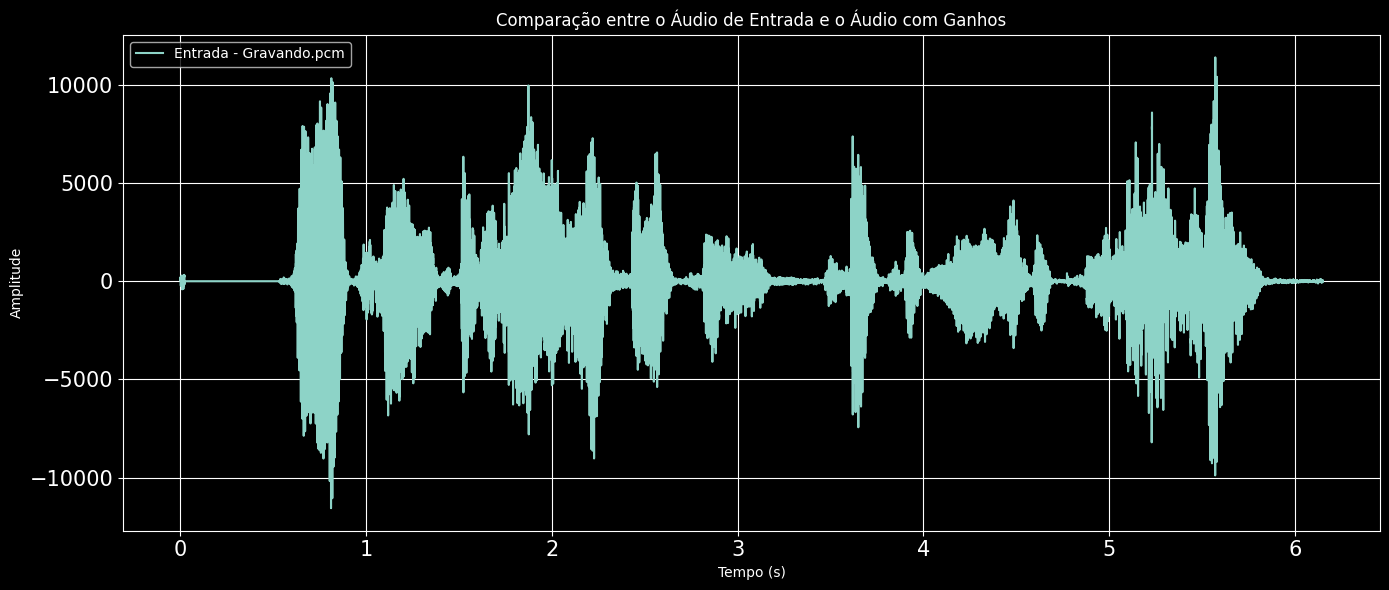

In [119]:
# Eixo do tempo
t_x = np.arange(len(x)) / Fs
t_y = np.arange(len(Eco)) / Fs

# Gráfico
plt.figure(figsize=(14, 6))

plt.plot(t_x, x, label='Entrada - Gravando.pcm')
#plt.plot(t_y, Eco, label='Saída - Gravando_com_eco.pcm', alpha=0.7)

plt.title('Comparação entre o Áudio de Entrada e o Áudio com Ganhos')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

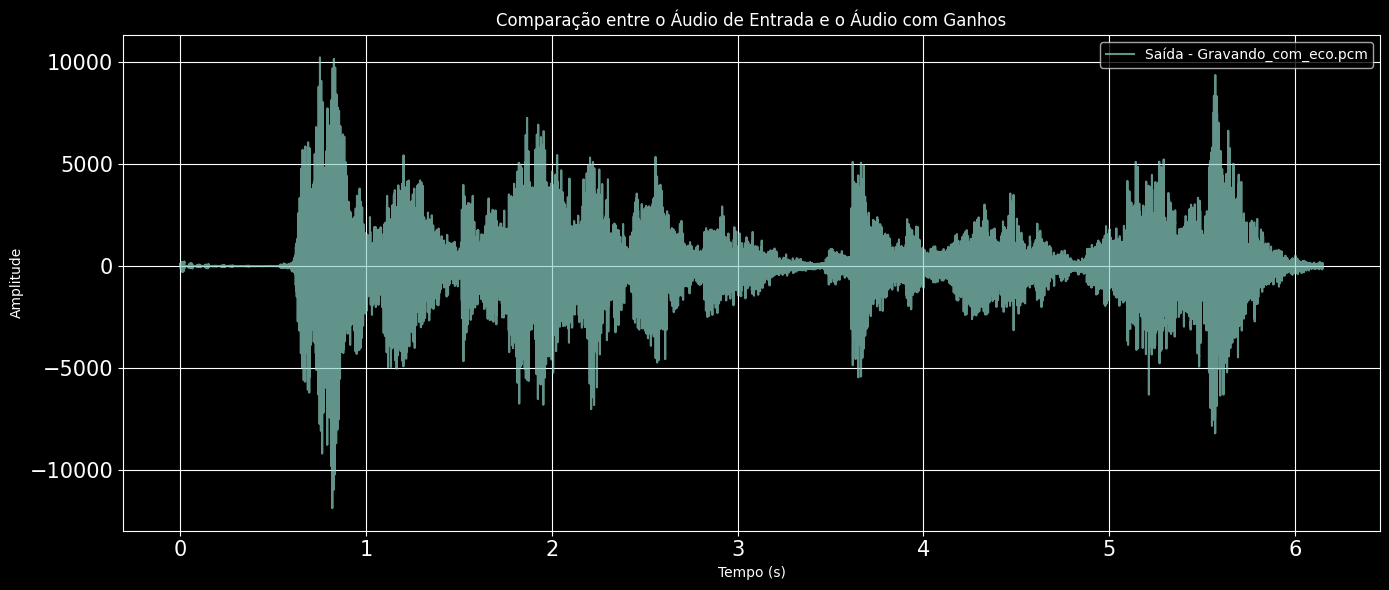

In [120]:
# Gráfico
plt.figure(figsize=(14, 6))

#plt.plot(t_x, x, label='Entrada - Gravando.pcm')
plt.plot(t_y, Eco, label='Saída - Gravando_com_eco.pcm', alpha=0.7)

plt.title('Comparação entre o Áudio de Entrada e o Áudio com Ganhos')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()